Gussing Game
=====

In [1]:
import os
import random
from pathlib import Path
from typing import TypedDict, List, Union, Annotated
from IPython.display import display
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage

/Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## No LLM

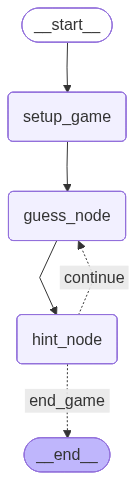

Attempt 0: guess number = 77 Current Range = (1, 100)
Attempt 1: guess number = 23 Current Range = (1, 76)
Attempt 2: guess number = 43 Current Range = (24, 76)
Attempt 3: guess number = 28 Current Range = (24, 42)
Attempt 4: guess number = 39 Current Range = (29, 42)
Attempt 5: guess number = 42 Current Range = (40, 42)
Success! Correct! You found the number in 6 attempts.


{'player_name': 'Welcome Kam!',
 'target_number': 42,
 'lower_bound': 40,
 'upper_bound': 42,
 'guesses': [77, 23, 43, 28, 39, 42],
 'attempts': 6,
 'hint': 'Correct! You found the number in 6 attempts.'}

In [2]:
class GameState(TypedDict):
    player_name: str  # provided by user
    target_number: int  # provided by user
    lower_bound: int  # provided by user
    upper_bound: int  # provided by user
    guesses: List[int]
    attempts: int
    hint: str

def setup_game(state: GameState) -> GameState:
    """Node that sets up the game state."""
    state["player_name"] = f"Welcome {state['player_name']}!"
    state['guesses'] = []
    state['attempts'] = 0
    state["hint"] = (
        "Game started! Try to guess the number "
        f"({state['lower_bound']}, {state['upper_bound']})"
    )
    return state

def make_a_guess(state: GameState) -> GameState:
    """Node that makes a random guess and increments the attempts."""
    possible_guesses = [
        i for i in range(state["lower_bound"], state["upper_bound"] + 1)
        if i not in state["guesses"]
    ]
    guess = random.choice(possible_guesses)
    print(
        f"Attempt {state['attempts']}: guess number = {guess} "
        f"Current Range = ({state['lower_bound']}, {state['upper_bound']})"
    )
    return {
        "guesses": state["guesses"] + [guess],
        "attempts": state["attempts"] + 1
    }

def get_hint(state: GameState) -> GameState:
    last_guess = state["guesses"][-1]
    target = state["target_number"]
    if last_guess < target:
        return {
            "hint": "Guess higher!",
            "lower_bound": last_guess + 1
        }
    elif last_guess > target:
        return {
            "hint": "Guess lower!",
            "upper_bound": last_guess - 1
        }
    msg = f"Correct! You found the number in {state['attempts']} attempts."
    print(f"Success! {msg}")
    return {"hint": msg}

def should_continue(state: GameState) -> str:
    """Node that decides whether to continue guessing or end the game."""
    if state["guesses"][-1] == state['target_number']:
        return "end_game"
    return "continue"
    
builder = StateGraph(GameState)
builder.add_node("setup_game", setup_game)
builder.add_node("guess_node", make_a_guess)
builder.add_node("hint_node", get_hint)
builder.add_edge(START, "setup_game")
builder.add_edge("setup_game", "guess_node")
builder.add_edge("guess_node", "hint_node")
builder.add_conditional_edges(
    "hint_node",
    should_continue,  # decide the next node based on the game state
    {"continue": "guess_node", "end_game": END}
)

graph = builder.compile()
display(graph)

graph.invoke(
    {'player_name': 'Kam', 'target_number': 42, 'lower_bound': 1, 'upper_bound': 100}
)

## LLM PLayer

In [3]:
project_root = Path().cwd().parent

load_dotenv(project_root / ".env")
assert os.getenv("GROQ_API_KEY"), "Please put GROQ API key in '.env' file"

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden"
)

llm.invoke("Hi").content

'Hello! How can I assist you today? 😊'

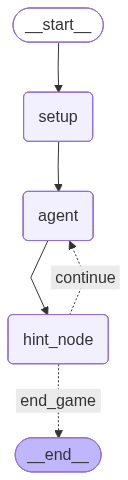

In [4]:
class GameState(TypedDict):
    target_number: int
    lower_bound: int = 1
    upper_bound: int = 100
    guesses: List[int | str]
    history: List[str]
    attempts: int


def setup_game(state: GameState) -> GameState:
    message = (
        "Welcome to the game! I have a number which you should guess!"
        f"Guess a number between ({state['lower_bound'], state['upper_bound']})"
    )
    return {
        "guesses": [],
        "history": [],
        "attempts": 0,
    }


def call_llm(state: GameState) -> GameState:
    system_prompt = """
You are a player in a number gussing game. You should try to guess the number in the least number of attemps as you can.
You will receive some hints during the game.
Only return a single number.
"""
    system_message = SystemMessage(content=system_prompt)
    prompt = f"""
Valid range: {state["lower_bound"]} to {state["upper_bound"]}
Previous guesses: {state["guesses"]}
Game history:
{chr(10).join(state["history"])}

Pick one integer inside the current valid range.
Do not repeat any previous guess.
Only return the integer.
"""
    response = llm.invoke([system_message, HumanMessage(prompt)])
    return {
        "guesses": state["guesses"] + [response.content],
        "attempts": state["attempts"] + 1
    }

def get_hint(state: GameState) -> GameState:
    last_guess = state["guesses"][-1]
    target = state["target_number"]
    try:
        last_guess = int(last_guess)
    except:
        msg = f"Your last guess was {last_guess}, which cannot be converted to int! Guess a valid number!"
        return {
            "history": state["history"] + [msg]
        }
    if last_guess < target:
        msg = f"Your last guess was {last_guess}, guess higher."
    elif last_guess > target:
        msg = f"Your last guess was {last_guess}, guess lower."
    else:
        msg = f"Correct! You guessed the number successfully after {state['attempts']}."
    print(f"Attempt {state['attempts']} {msg}")
    return {
        "history": state["history"] + [msg]
    }

def should_continue(state: GameState) -> str:
    last_guess = state["guesses"][-1]
    target = state["target_number"]
    try:
        last_guess = int(last_guess)
    except:
        return "continue"
    if last_guess == target:
        return "end_game"
    return "continue"


builder = StateGraph(GameState)
builder.add_node("setup", setup_game)
builder.add_node("agent", call_llm)
builder.add_node("hint_node", get_hint)
builder.add_edge(START, "setup")
builder.add_edge("setup", "agent")
builder.add_edge("agent", "hint_node")
builder.add_conditional_edges(
    "hint_node",
    should_continue,
    {"continue": "agent", "end_game": END}
)

graph = builder.compile()
display(graph)

In [5]:
rand_number = random.randint(1, 100)
print(f"===== GAME STARTED -- secret number is {rand_number} =====")

graph.invoke(
    {'target_number': rand_number, 'lower_bound': 1, 'upper_bound': 100}
)

===== GAME STARTED -- secret number is 98 =====
Attempt 1 Your last guess was 50, guess higher.
Attempt 2 Your last guess was 75, guess higher.
Attempt 3 Your last guess was 88, guess higher.
Attempt 4 Your last guess was 95, guess higher.
Attempt 5 Your last guess was 96, guess higher.
Attempt 6 Your last guess was 97, guess higher.
Attempt 7 Correct! You guessed the number successfully after 7.


{'target_number': 98,
 'lower_bound': 1,
 'upper_bound': 100,
 'guesses': ['50', '75', '88', '95', '96', '97', '98'],
 'history': ['Your last guess was 50, guess higher.',
  'Your last guess was 75, guess higher.',
  'Your last guess was 88, guess higher.',
  'Your last guess was 95, guess higher.',
  'Your last guess was 96, guess higher.',
  'Your last guess was 97, guess higher.',
  'Correct! You guessed the number successfully after 7.'],
 'attempts': 7}